# EMNIST Letters Classification using HOG + SVM

## Midterm Project Machine Learning Pipeline

### Nama: [Aidan Predella N]
### NIM: [4222301077]

## 1. Import Library

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from skimage.feature import hog
from skimage import exposure

import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset

In [2]:
# Load dataset
file_path = 'emnist-letters-train.csv'

df = pd.read_csv(file_path, header=None)

print(df.shape)
df.head()


(88800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Shuffle Dataset

In [3]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)


(88800, 785)


## 4. Prepare Balanced Dataset (2600 Samples)

In [4]:
labels = df.iloc[:, 0]

balanced_data = []
for label in sorted(labels.unique()):
    class_data = df[df[0] == label].head(100)
    balanced_data.append(class_data)

balanced_df = pd.concat(balanced_data)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df.shape)
print("\nSample balanced data:")
print(balanced_df.head())
print("\nLabel distribution:")
print(balanced_df.iloc[:, 0].value_counts().sort_index())

(2600, 785)

Sample balanced data:
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0   16    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    2    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    3    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3   22    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4   16    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]

Label distribution:
0
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24 

## 5. Separate Features and Labels

In [5]:
X = balanced_df.iloc[:, 1:].values
Y = balanced_df.iloc[:, 0].values

print(X.shape)
print(Y.shape)


(2600, 784)
(2600,)


## 6. Visualize Dataset

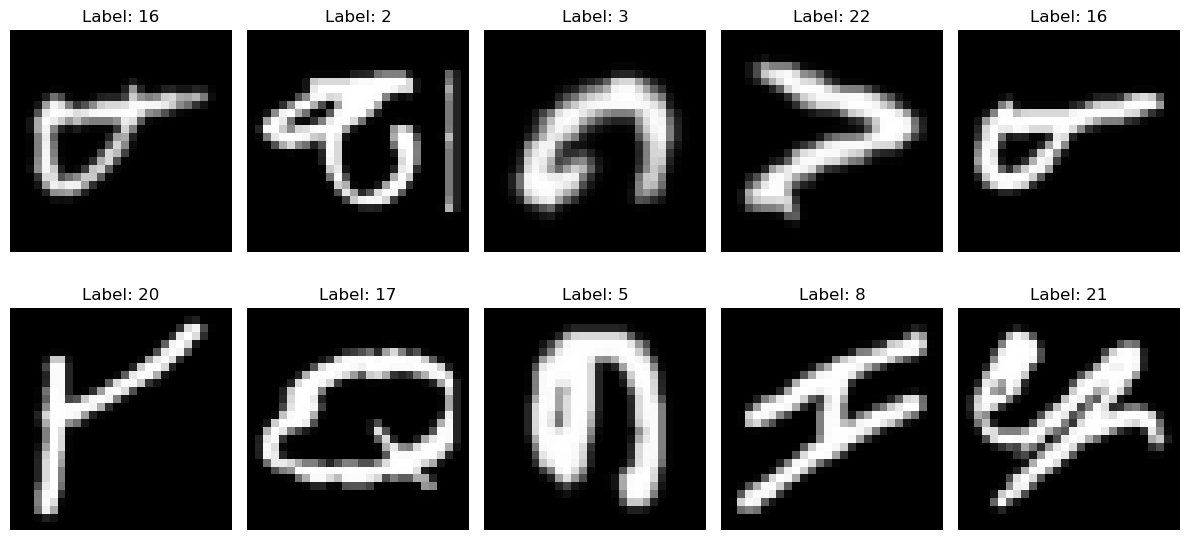

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = X[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {Y[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## 7. HOG Feature Extraction

In [7]:
hog_features = []

for image in X:
    image = image.reshape(28, 28)

    features = hog(
        image,
        orientations=12,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    hog_features.append(features)

hog_features = np.array(hog_features)

print(hog_features.shape)


(2600, 1728)


## 8. Visualize HOG Image

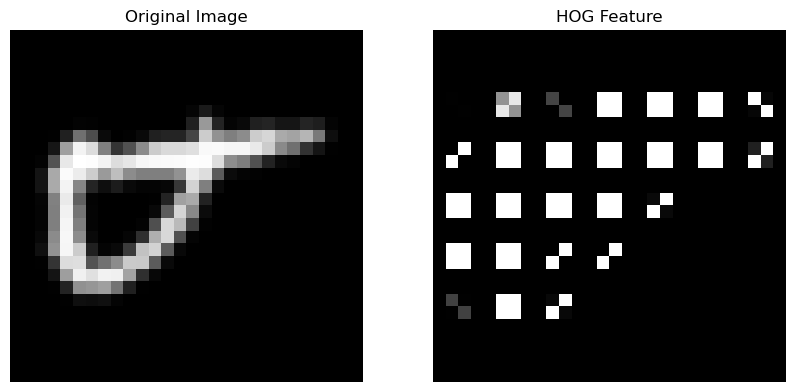

In [8]:
sample_image = X[0].reshape(28, 28)

fd, hog_image = hog(
    sample_image,
    orientations=12,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(sample_image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(hog_image_rescaled, cmap='gray')
ax[1].set_title('HOG Feature')
ax[1].axis('off')

plt.show()


## 9. Split Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    hog_features,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print('Training Data :', X_train.shape)
print('Testing Data  :', X_test.shape)


Training Data : (2080, 1728)
Testing Data  : (520, 1728)


## 10. Leave One Out Cross Validation (LOOCV)

In [10]:
loo = LeaveOneOut()

print('Total LOOCV Iteration :', loo.get_n_splits(X_train))


Total LOOCV Iteration : 2080


## 11. Grid Search for Best SVM Parameters

In [11]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

svm = SVC()

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best Parameters :')
print(grid_search.best_params_)

print('\nBest Accuracy :')
print(grid_search.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters :
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Accuracy :
0.8302884615384617


## 12. Train Best Model

In [12]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)


,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 13. Prediction

In [13]:
train_pred = best_model.predict(X_train)

test_pred = best_model.predict(X_test)


## 14. Training Evaluation

In [14]:
train_accuracy = accuracy_score(y_train, train_pred)
train_precision = precision_score(y_train, train_pred, average='weighted')
train_recall = recall_score(y_train, train_pred, average='weighted')
train_f1 = f1_score(y_train, train_pred, average='weighted')

print('=== TRAINING PERFORMANCE ===')
print('Accuracy :', train_accuracy)
print('Precision:', train_precision)
print('Recall   :', train_recall)
print('F1-Score :', train_f1)


=== TRAINING PERFORMANCE ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


## 15. Testing Evaluation

In [15]:
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, average='weighted')
test_recall = recall_score(y_test, test_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

print('=== TESTING PERFORMANCE ===')
print('Accuracy :', test_accuracy)
print('Precision:', test_precision)
print('Recall   :', test_recall)
print('F1-Score :', test_f1)


=== TESTING PERFORMANCE ===
Accuracy : 0.8576923076923076
Precision: 0.8653061620777148
Recall   : 0.8576923076923076
F1-Score : 0.8580332576514821


## 16. Classification Report

In [16]:
print(classification_report(y_test, test_pred))


              precision    recall  f1-score   support

           1       0.67      0.80      0.73        20
           2       0.90      0.90      0.90        20
           3       0.95      0.95      0.95        20
           4       0.82      0.90      0.86        20
           5       0.95      0.90      0.92        20
           6       0.86      0.90      0.88        20
           7       0.86      0.60      0.71        20
           8       0.73      0.95      0.83        20
           9       0.60      0.75      0.67        20
          10       0.83      0.75      0.79        20
          11       0.90      0.90      0.90        20
          12       0.72      0.65      0.68        20
          13       1.00      0.90      0.95        20
          14       0.95      0.95      0.95        20
          15       0.91      1.00      0.95        20
          16       0.86      0.90      0.88        20
          17       0.68      0.75      0.71        20
          18       0.88    

## 17. Confusion Matrix

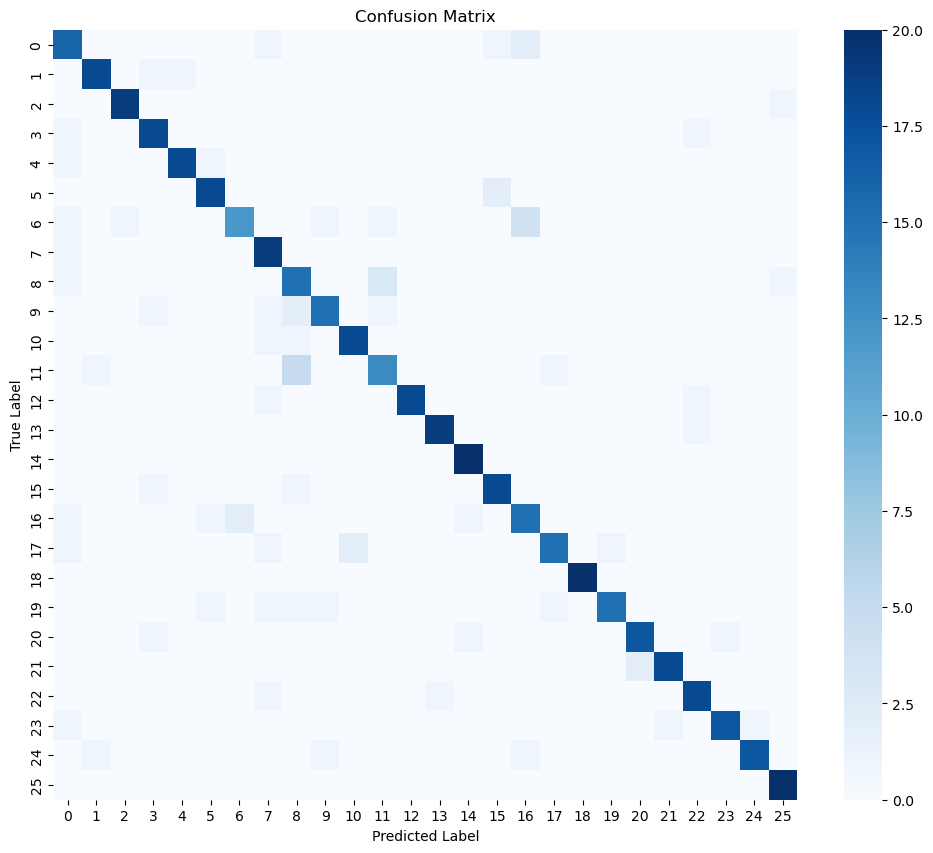

In [17]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(12,10))

sns.heatmap(cm, annot=False, cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()


## 18. Conclusion

Pada project ini dilakukan klasifikasi karakter tulisan tangan menggunakan dataset EMNIST Letters dengan metode:

- HOG (Histogram of Oriented Gradients) sebagai feature extraction
- Support Vector Machine (SVM) sebagai classifier

Tahapan yang dilakukan:
1. Dataset preparation
2. Dataset balancing
3. HOG feature extraction
4. SVM classification
5. Grid Search parameter tuning
6. Evaluation menggunakan accuracy, precision, recall, F1-score, dan confusion matrix
